Device: cpu
=== Dataset Summary (UNSW-NB15) ===
Shape: (257499, 34)
Unique Attack Categories: 9
Counts per category:
 Attack Type
Normal Traffic    93000
Generic           58871
Exploits          44525
Fuzzers           24246
DoS               16353
Reconnaissance    13987
Analysis           2677
Backdoor           2329
Shellcode          1511
Name: count, dtype: int64


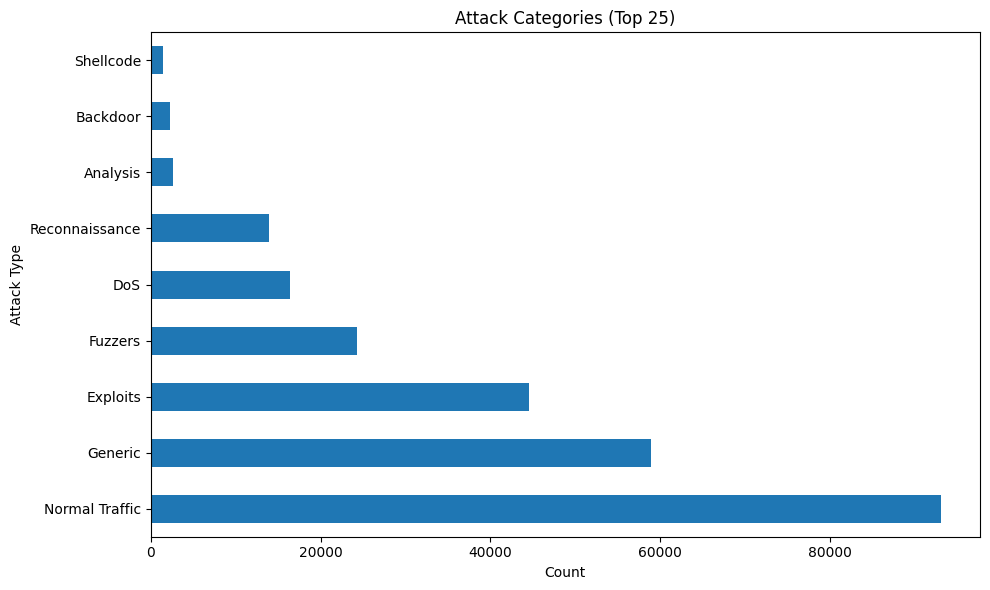

=== Feature Selection ===
Selected feature count: 34
Selected features list (first 50 shown):
['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'is_sm_ips_ports']
Params: {'lr': 0.0003, 'epochs': 3, 'batch': 128} F1: 0.9241863905325444
Params: {'lr': 0.0003, 'epochs': 3, 'batch': 256} F1: 0.9226271397038401
Params: {'lr': 0.0003, 'epochs': 5, 'batch': 128} F1: 0.9254481886483672
Params: {'lr': 0.0003, 'epochs': 5, 'batch': 256} F1: 0.9251601418294836
Params: {'lr': 0.0001, 'epochs': 3, 'batch': 128} F1: 0.9210773884474549
Params: {'lr': 0.0001, 'epochs': 3, 'batch': 256} F1: 0.9166244373565445
Params: {'lr': 0.0001, 'epochs': 5, 'batch': 128} F1: 0.9175953917189309
Params: {'lr'

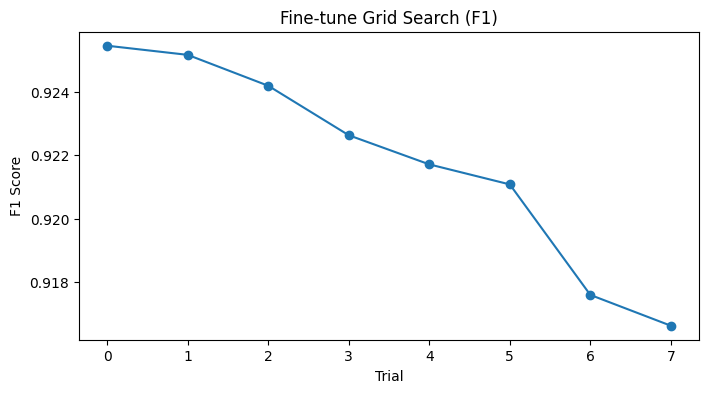

[Meta 20/100] update applied
[Meta 40/100] update applied
[Meta 60/100] update applied
[Meta 80/100] update applied
[Meta 100/100] update applied
Meta-training finished.
Epoch 1: acc=0.8784, f1=0.9029
Epoch 2: acc=0.8928, f1=0.9170
Epoch 3: acc=0.8916, f1=0.9143
Epoch 4: acc=0.8910, f1=0.9121
Epoch 5: acc=0.8952, f1=0.9171
Epoch 6: acc=0.8897, f1=0.9105
Epoch 7: acc=0.8923, f1=0.9134
Epoch 8: acc=0.8943, f1=0.9148
Epoch 9: acc=0.8972, f1=0.9175
Epoch 10: acc=0.8905, f1=0.9103

===== Final Metrics =====
Accuracy : 0.90
Precision: 0.94
Recall   : 0.90
F1 Score : 0.92
Confusion Matrix:
 [[16748  1852]
 [ 3443 29457]]
TPR=0.8953, TNR=0.9004, FPR=0.0996, FNR=0.1047

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.90      0.86     18600
           1       0.94      0.90      0.92     32900

    accuracy                           0.90     51500
   macro avg       0.89      0.90      0.89     51500
weighted avg       0.90      0.90 

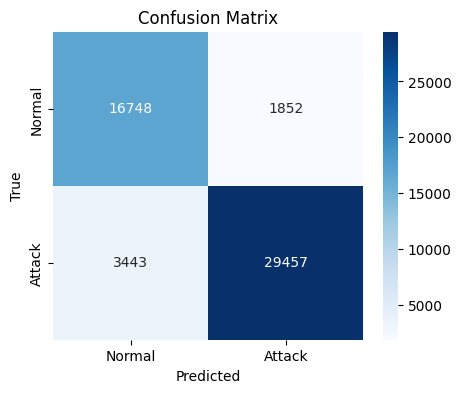

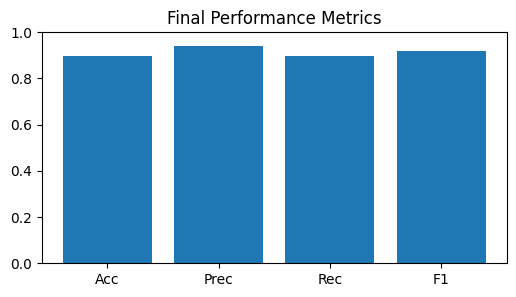

In [1]:
# ================================
# Cell 1: Imports & Reproducibility
# ================================
import os, random, time, math
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# Reproducibility
def set_seed(seed=42):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ======================================
# Cell 2: Dataset Loading + Preprocessing (UNSW-NB15)
# ======================================
def load_unsw_nb15(train_path, test_path, min_samples_per_attack=200):
    """
    Load and preprocess UNSW-NB15 dataset to match CICIDS interface.
    Returns:
        X: np.ndarray [n_samples, n_features] (standardized)
        y_attack: np.ndarray of string labels (Attack Type, with Normal Traffic)
        feature_names: list of feature column names
        counts: pd.Series of counts per Attack Type (after filtering)
    """
    # Load both training and testing CSVs
    df_train = pd.read_csv(train_path)
    df_test = pd.read_csv(test_path)

    # Combine into one dataframe
    df = pd.concat([df_train, df_test], axis=0, ignore_index=True)

    # Drop fully-empty cols and rows with NaNs
    df = df.dropna(axis=1, how='all').dropna()

    # Validate expected columns
    if 'attack_cat' not in df.columns:
        raise ValueError("Expected column 'attack_cat' not found")
    if 'label' not in df.columns:
        raise ValueError("Expected column 'label' not found")

    # Build compatible target column:
    # Map label=0 to 'Normal Traffic', else use attack_cat string
    df['attack_cat'] = df['attack_cat'].astype(str)
    df['Attack Type'] = np.where(df['label'] == 0, 'Normal Traffic', df['attack_cat'])
    # Normalize any blanks to Normal Traffic
    df.loc[df['Attack Type'].isin(['', 'nan', 'None', 'NaN']), 'Attack Type'] = 'Normal Traffic'
    df['Attack Type'] = df['Attack Type'].astype(str)

    # Label-encode categorical features (exclude target)
    for col in ['proto', 'service', 'state']:
        if col in df.columns:
            df[col] = LabelEncoder().fit_transform(df[col].astype(str))

    # Filter small categories but always keep Normal Traffic
    counts_full = df['Attack Type'].value_counts()
    good_labels = counts_full[counts_full >= min_samples_per_attack].index.tolist()
    if 'Normal Traffic' in counts_full.index and 'Normal Traffic' not in good_labels:
        good_labels.append('Normal Traffic')

    df = df[df['Attack Type'].isin(good_labels)].copy()
    counts = df['Attack Type'].value_counts()

    # Build features
    drop_cols = ['Attack Type', 'attack_cat', 'label']
    drop_cols += [c for c in df.columns if 'id' in c.lower() or 'index' in c.lower()]
    X_df = df.drop(columns=[c for c in drop_cols if c in df.columns])

    # Standardize
    X = StandardScaler().fit_transform(X_df.values)
    y_attack = df['Attack Type'].values
    feature_names = X_df.columns.tolist()

    return X, y_attack, feature_names, counts

# Paths for UNSW-NB15 dataset
train_path = r"C:\Users\mchan\OneDrive\Pictures\Documents\4-1 Subjects\Mini Project\UNSW_NB15\UNSW_NB15\UNSW_NB15_training-set.csv"
test_path  = r"C:\Users\mchan\OneDrive\Pictures\Documents\4-1 Subjects\Mini Project\UNSW_NB15\UNSW_NB15\UNSW_NB15_testing-set.csv"

# Load UNSW-NB15 with same interface/variables as CICIDS
X_all, y_attack, feature_names, counts = load_unsw_nb15(train_path, test_path, min_samples_per_attack=200)

print("=== Dataset Summary (UNSW-NB15) ===")
print("Shape:", X_all.shape)
print("Unique Attack Categories:", np.unique(y_attack).shape[0])
print("Counts per category:\n", counts)

# Plot attack category distribution (top 25)
plt.figure(figsize=(10,6))
counts[:25].plot(kind="barh")
plt.title("Attack Categories (Top 25)")
plt.xlabel("Count")
plt.tight_layout()
plt.show()

# ===================================
# Cell 3: Feature Selection (FastQAOA)
# ===================================
class FastQAOA:
    def __init__(self, X, y, rng_seed=42):
        self.X = X
        self.y = y
        self.rng = np.random.RandomState(rng_seed)
        self.n = X.shape[1]
    def optimize(self, n_features=60):
        scores = []
        ynum = (np.array(self.y) != 'Normal Traffic').astype(int)
        for j in range(self.n):
            col = self.X[:, j]
            try:
                corr = abs(np.corrcoef(col, ynum)[0,1])
            except:
                corr = 0.0
            scores.append(corr * np.var(col))
        idx = np.argsort(scores)[-n_features:]
        return np.sort(idx)

# Run fast QAOA feature selector
q = FastQAOA(X_all, y_attack)
selected_idx = q.optimize(n_features=min(120, X_all.shape[1]))
X_sel = X_all[:, selected_idx]

print("=== Feature Selection ===")
print("Selected feature count:", len(selected_idx))
selected_feature_names = [feature_names[i] for i in selected_idx]
print("Selected features list (first 50 shown):")
print(selected_feature_names[:50])

# ===================================
# Cell 4: Hyperparameter Tuning Stage
# ===================================
from sklearn.model_selection import StratifiedShuffleSplit

# Binary labels (Normal vs Attack)
binary_labels_all = (y_attack != 'Normal Traffic').astype(int)

# Quick stratified split (80/20)
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx_quick, val_idx_quick = next(sss.split(X_sel, binary_labels_all))
X_quick_train, y_quick_train = X_sel[train_idx_quick], binary_labels_all[train_idx_quick]
X_quick_val, y_quick_val = X_sel[val_idx_quick], binary_labels_all[val_idx_quick]

# Model (BiLSTM + Multihead Attention)
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim, num_heads, attn_dropout=0.0):
        super().__init__()
        assert embed_dim % num_heads == 0
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.qkv = nn.Linear(embed_dim, embed_dim * 3)
        self.out = nn.Linear(embed_dim, embed_dim)
        self.drop = nn.Dropout(attn_dropout)
    def forward(self, x):
        B, T, C = x.size()
        qkv = self.qkv(x).reshape(B, T, 3, self.num_heads, self.head_dim).permute(2,0,3,1,4)
        q,k,v = qkv[0], qkv[1], qkv[2]
        attn = (q @ k.transpose(-2,-1)) / math.sqrt(self.head_dim)
        attn = torch.softmax(attn, dim=-1)
        out = (attn @ v).transpose(1,2).reshape(B,T,C)
        out = self.drop(out)
        return self.out(out)

class IDSModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_heads=4, dropout=0.1, num_classes=2):
        super().__init__()
        self.bilstm = nn.LSTM(input_size=input_dim, hidden_size=hidden_dim,
                              batch_first=True, bidirectional=True)
        self.attn = MultiHeadSelfAttention(embed_dim=hidden_dim*2, num_heads=num_heads)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim*2, num_classes)
    def forward(self, x):
        if x.dim()==2: x = x.unsqueeze(1)
        lstm_out,_ = self.bilstm(x)
        attn_out = self.attn(lstm_out)
        out = attn_out[:,-1,:]
        out = self.dropout(out)
        return self.fc(out)

input_dim = X_sel.shape[1]
def model_fn_factory(hidden_dim=64, num_heads=4, dropout=0.1):
    return IDSModel(input_dim=input_dim, hidden_dim=hidden_dim,
                    num_heads=num_heads, dropout=dropout)

# Grid search on fine-tune params
param_grid = [{'lr':lr,'epochs':ep,'batch':bs}
              for lr in [3e-4,1e-4]
              for ep in [3,5]
              for bs in [128,256]]

results = []
for params in param_grid:
    model = model_fn_factory().to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=params['lr'])
    crit = nn.CrossEntropyLoss()
    # train
    ds = TensorDataset(torch.tensor(X_quick_train,dtype=torch.float32),
                       torch.tensor(y_quick_train,dtype=torch.long))
    loader = DataLoader(ds, batch_size=params['batch'], shuffle=True)
    model.train()
    for e in range(params['epochs']):
        for xb,yb in loader:
            xb,yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = crit(model(xb), yb); loss.backward(); opt.step()
    # eval
    model.eval()
    with torch.no_grad():
        val_out = model(torch.tensor(X_quick_val,dtype=torch.float32).to(device))
        preds = torch.argmax(val_out, dim=1).cpu().numpy()
    f1 = f1_score(y_quick_val, preds, zero_division=0)
    results.append({**params,'f1':f1})
    print("Params:",params,"F1:",f1)

results_df = pd.DataFrame(results).sort_values('f1',ascending=False)
print("\n=== Hyperparameter Tuning Results ===")
print(results_df)

plt.figure(figsize=(8,4))
plt.plot(results_df['f1'].values, marker='o')
plt.title("Fine-tune Grid Search (F1)")
plt.xlabel("Trial"); plt.ylabel("F1 Score")
plt.show()

# ===================================
# Cell 5: MAML (Reptile) Training
# ===================================
def sample_task_batch(task, X, y_attack, support_k=20, query_k=40, rng=None):
    if rng is None: rng = np.random.RandomState()
    pos, neg = task['pos_idx'], task['neg_idx']
    pos_perm = rng.choice(pos, size=min(len(pos), support_k+query_k), replace=False)
    neg_perm = rng.choice(neg, size=min(len(neg), support_k+query_k), replace=False)
    pos_sup, pos_q = pos_perm[:support_k], pos_perm[support_k:support_k+query_k]
    neg_sup, neg_q = neg_perm[:support_k], neg_perm[support_k:support_k+query_k]
    support_idx = np.concatenate([pos_sup,neg_sup])
    query_idx   = np.concatenate([pos_q,neg_q])
    y_sup = (y_attack[support_idx] != 'Normal Traffic').astype(int)
    y_q   = (y_attack[query_idx] != 'Normal Traffic').astype(int)
    return support_idx, query_idx, X[support_idx], y_sup, X[query_idx], y_q

def build_tasks(X,y_attack,normal_label='Normal Traffic',min_support=100):
    labels = np.unique(y_attack); tasks=[]
    for lab in labels:
        if lab==normal_label: continue
        idx_pos = np.where(y_attack==lab)[0]
        idx_neg = np.where(y_attack==normal_label)[0]
        if len(idx_pos)<min_support or len(idx_neg)<min_support: continue
        tasks.append({'attack_label':lab,'pos_idx':idx_pos,'neg_idx':idx_neg})
    return tasks

tasks = build_tasks(X_sel, y_attack)

def reptile_meta_train(X,y_attack,tasks,model_fn,meta_iters=100,tasks_per_iter=4,
                       inner_steps=5,inner_lr=1e-2,meta_lr=0.1,
                       support_k=30,query_k=60):
    rng = np.random.RandomState(42)
    meta_model = model_fn().to(device)
    loss_fn = nn.CrossEntropyLoss()
    for it in range(1,meta_iters+1):
        sampled = rng.choice(tasks, size=min(tasks_per_iter,len(tasks)), replace=False)
        task_diffs=[]
        for task in sampled:
            worker = model_fn().to(device)
            worker.load_state_dict(meta_model.state_dict())
            opt = torch.optim.SGD(worker.parameters(), lr=inner_lr)
            s_idx,q_idx,Xs,ys,Xq,yq = sample_task_batch(task,X,y_attack,
                                                        support_k=support_k,query_k=query_k,rng=rng)
            ds = TensorDataset(torch.tensor(Xs,dtype=torch.float32), torch.tensor(ys,dtype=torch.long))
            loader = DataLoader(ds, batch_size=min(32,len(Xs)), shuffle=True)
            worker.train()
            for _ in range(inner_steps):
                for xb,yb in loader:
                    xb,yb = xb.to(device), yb.to(device)
                    opt.zero_grad()
                    loss = loss_fn(worker(xb), yb)
                    loss.backward(); opt.step()
            diff={}; 
            for n,p in meta_model.state_dict().items():
                diff[n]=worker.state_dict()[n]-p
            task_diffs.append(diff)
        # aggregate
        new_state=meta_model.state_dict()
        for n in new_state.keys():
            avg=sum(d[n] for d in task_diffs)/len(task_diffs)
            new_state[n]=new_state[n]+meta_lr*avg
        meta_model.load_state_dict(new_state)
        if it%20==0: print(f"[Meta {it}/{meta_iters}] update applied")
    return meta_model

set_seed(42)
meta_model = reptile_meta_train(X_sel,y_attack,tasks,
                                model_fn=lambda: model_fn_factory(),
                                meta_iters=100)
print("Meta-training finished.")

# ===================================
# Cell 6: Final Fine-tune & Evaluation
# ===================================
binary_labels = (y_attack!='Normal Traffic').astype(int)
train_idx,test_idx = train_test_split(np.arange(len(binary_labels)),
                                      test_size=0.2,stratify=binary_labels,random_state=42)
X_train_final,X_test_final = X_sel[train_idx],X_sel[test_idx]
y_train_final,y_test_final = binary_labels[train_idx],binary_labels[test_idx]

ft_model = model_fn_factory().to(device)
ft_model.load_state_dict(meta_model.state_dict())

train_ds = TensorDataset(torch.tensor(X_train_final,dtype=torch.float32),
                         torch.tensor(y_train_final,dtype=torch.long))
test_ds = TensorDataset(torch.tensor(X_test_final,dtype=torch.float32),
                        torch.tensor(y_test_final,dtype=torch.long))
train_loader = DataLoader(train_ds,batch_size=256,shuffle=True)
test_loader  = DataLoader(test_ds,batch_size=512,shuffle=False)

class_counts = np.bincount(y_train_final)
weights = torch.tensor([1/(class_counts[0]+1e-8),1/(class_counts[1]+1e-8)],
                       dtype=torch.float32).to(device)
weights = weights/weights.sum()
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.AdamW(ft_model.parameters(), lr=3e-4, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,'max',factor=0.5,patience=2)

best_f1=0.0
for ep in range(1,11):
    ft_model.train()
    for xb,yb in train_loader:
        xb,yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(ft_model(xb), yb)
        loss.backward(); optimizer.step()
    # eval
    ft_model.eval(); preds=[]; gts=[]
    with torch.no_grad():
        for xb,yb in test_loader:
            xb=xb.to(device)
            out=ft_model(xb)
            p=torch.argmax(out,dim=1).cpu().numpy()
            preds.append(p); gts.append(yb.numpy())
    preds=np.concatenate(preds); gts=np.concatenate(gts)
    f1=f1_score(gts,preds,zero_division=0)
    acc=accuracy_score(gts,preds)
    scheduler.step(f1)
    print(f"Epoch {ep}: acc={acc:.4f}, f1={f1:.4f}")
    if f1>best_f1:
        best_f1=f1
        torch.save(ft_model.state_dict(),"best_ft_model.pth")

ft_model.load_state_dict(torch.load("best_ft_model.pth"))
ft_model.eval(); preds=[]
with torch.no_grad():
    for xb,_ in test_loader:
        xb=xb.to(device)
        preds.append(torch.argmax(ft_model(xb),dim=1).cpu().numpy())
preds=np.concatenate(preds)

acc=accuracy_score(y_test_final,preds)
prec=precision_score(y_test_final,preds,zero_division=0)
rec=recall_score(y_test_final,preds,zero_division=0)
f1=f1_score(y_test_final,preds,zero_division=0)
cm=confusion_matrix(y_test_final,preds)

tn,fp,fn,tp = cm.ravel()
tpr = tp/(tp+fn); tnr = tn/(tn+fp)
fpr = fp/(fp+tn); fnr = fn/(fn+tp)

print("\n===== Final Metrics =====")
print(f"Accuracy : {acc:.2f}")
print(f"Precision: {prec:.2f}")
print(f"Recall   : {rec:.2f}")
print(f"F1 Score : {f1:.2f}")
print("Confusion Matrix:\n",cm)
print(f"TPR={tpr:.4f}, TNR={tnr:.4f}, FPR={fpr:.4f}, FNR={fnr:.4f}")
print("\nClassification Report:\n", classification_report(y_test_final,preds))

# Plot confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
            xticklabels=['Normal','Attack'],yticklabels=['Normal','Attack'])
plt.title("Confusion Matrix"); plt.xlabel("Predicted"); plt.ylabel("True")
plt.show()

# Metrics bar chart
plt.figure(figsize=(6,3))
plt.bar(['Acc','Prec','Rec','F1'],[acc,prec,rec,f1])
plt.ylim(0,1); plt.title("Final Performance Metrics")
plt.show()


Device: cpu
=== Dataset Summary (UNSW-NB15, Advanced) ===
Shape: (257499, 45)
Unique Attack Categories: 9
Counts per category:
 Attack Type
Normal Traffic    93000
Generic           58871
Exploits          44525
Fuzzers           24246
DoS               16353
Reconnaissance    13987
Analysis           2677
Backdoor           2329
Shellcode          1511
Name: count, dtype: int64


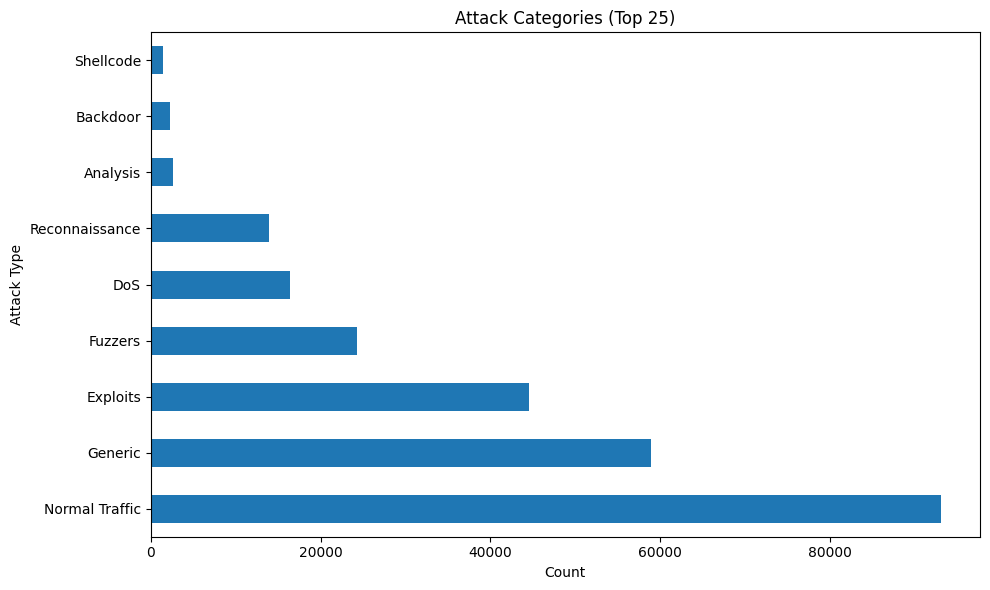

C:\Users\mchan\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\mchan\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


=== Feature Selection ===
Selected feature count: 45
Selected features list (first 50 shown):
['total_bytes', 'sbytes', 'throughput', 'sload', 'rate', 'rate_log', 'smean', 'dur_log', 'dur', 'dbytes', 'dinpkt', 'bytes_ratio', 'total_pkts', 'pkts_ratio', 'dload', 'dmean', 'load_ratio', 'dpkts', 'tcprtt', 'synack', 'ackdat', 'sinpkt', 'state', 'state_freq', 'sjit', 'ct_dst_sport_ltm', 'spkts', 'djit', 'sloss', 'proto', 'ct_src_dport_ltm', 'swin', 'dloss', 'proto_freq', 'dwin', 'stcpb', 'dtcpb', 'service_freq', 'service', 'response_body_len', 'ct_ftp_cmd', 'trans_depth', 'is_ftp_login', 'ct_flw_http_mthd', 'is_sm_ips_ports']
Params: {'lr': 0.0003, 'epochs': 3, 'batch': 128} F1: 0.9303166892769098
Params: {'lr': 0.0003, 'epochs': 3, 'batch': 256} F1: 0.9324912365526411
Params: {'lr': 0.0003, 'epochs': 5, 'batch': 128} F1: 0.9346888931393176
Params: {'lr': 0.0003, 'epochs': 5, 'batch': 256} F1: 0.9336643139131475
Params: {'lr': 0.0001, 'epochs': 3, 'batch': 128} F1: 0.9293380244212518
Params

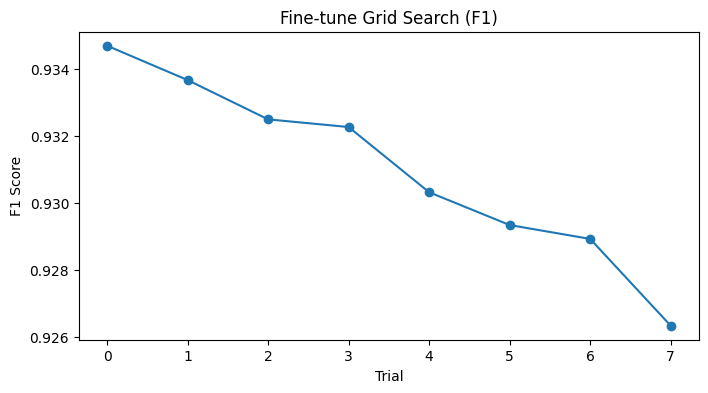

[Meta 20/100] update applied
[Meta 40/100] update applied
[Meta 60/100] update applied
[Meta 80/100] update applied
[Meta 100/100] update applied
Meta-training finished.
Epoch 1: acc=0.8801, f1=0.8996
Epoch 2: acc=0.8928, f1=0.9107
Epoch 3: acc=0.9119, f1=0.9304
Epoch 4: acc=0.9138, f1=0.9309
Epoch 5: acc=0.9117, f1=0.9286
Epoch 6: acc=0.9139, f1=0.9310
Epoch 7: acc=0.9052, f1=0.9213
Epoch 8: acc=0.9112, f1=0.9277
Epoch 9: acc=0.9156, f1=0.9321
Epoch 10: acc=0.9133, f1=0.9297

===== Final Metrics =====
Accuracy : 0.92
Precision: 0.96
Recall   : 0.91
F1 Score : 0.93
Confusion Matrix:
 [[17344  1256]
 [ 3090 29810]]
TPR=0.9061, TNR=0.9325, FPR=0.0675, FNR=0.0939

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.93      0.89     18600
           1       0.96      0.91      0.93     32900

    accuracy                           0.92     51500
   macro avg       0.90      0.92      0.91     51500
weighted avg       0.92      0.92 

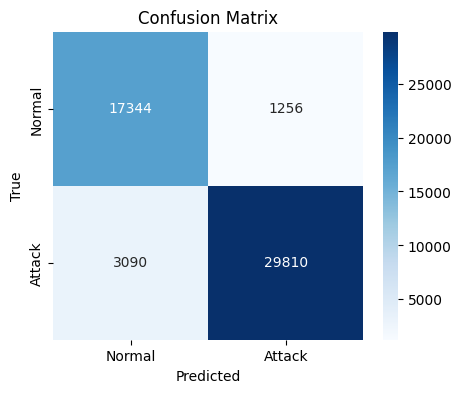

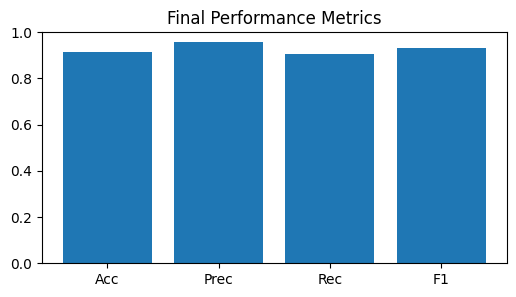

In [2]:
# ================================
# Cell 1: Imports & Reproducibility
# ================================
import os, random, time, math
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# Reproducibility
def set_seed(seed=42):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ======================================
# Cell 2: Advanced Dataset Loading + Preprocessing (UNSW-NB15)
# ======================================
def load_unsw_nb15_advanced(train_path, test_path, min_samples_per_attack=200):
    
    df_train = pd.read_csv(train_path)
    df_test = pd.read_csv(test_path)
    df = pd.concat([df_train, df_test], axis=0, ignore_index=True)

    # Handle missing values and empty columns
    df = df.fillna(0)
    df = df.dropna(axis=1, how='all')

    # Validate expected columns
    if 'attack_cat' not in df.columns or 'label' not in df.columns:
        raise ValueError("UNSW-NB15 must contain 'attack_cat' and 'label' columns")

    # Build target to match the rest of the pipeline exactly
    # Map label=0 to 'Normal Traffic', else use attack_cat
    df['attack_cat'] = df['attack_cat'].astype(str)
    df['Attack Type'] = np.where(df['label'] == 0, 'Normal Traffic', df['attack_cat']).astype(str)
    df.loc[df['Attack Type'].isin(['', 'nan', 'NaN', 'None']), 'Attack Type'] = 'Normal Traffic'

    # Categorical encodings (proto, service, state)
    # Add frequency-encoded companion columns to enrich signal
    for col in ['proto', 'service', 'state']:
        if col in df.columns:
            freq_map = df[col].astype(str).value_counts().to_dict()
            df[col + '_freq'] = df[col].astype(str).map(freq_map).astype(float)
            df[col] = LabelEncoder().fit_transform(df[col].astype(str))

    # IQR-based outlier capping for numeric features (preserve distribution)
    target_cols = ['Attack Type', 'attack_cat', 'label']
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols = [c for c in numeric_cols if c not in target_cols]
    for col in numeric_cols:
        col_series = df[col]
        if col_series.std() > 0:
            Q1 = col_series.quantile(0.25)
            Q3 = col_series.quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - 2.0 * IQR
            upper = Q3 + 2.0 * IQR
            df[col] = np.clip(col_series, lower, upper)

    # Network-specific engineered features
    if {'sbytes','dbytes'}.issubset(df.columns):
        df['bytes_ratio'] = df['sbytes'] / (df['dbytes'] + 1e-8)
        df['total_bytes'] = df['sbytes'] + df['dbytes']
    if {'spkts','dpkts'}.issubset(df.columns):
        df['pkts_ratio'] = df['spkts'] / (df['dpkts'] + 1e-8)
        df['total_pkts'] = df['spkts'] + df['dpkts']
    if {'sload','dload'}.issubset(df.columns):
        df['load_ratio'] = df['sload'] / (df['dload'] + 1e-8)
    if 'dur' in df.columns:
        df['dur_log'] = np.log1p(df['dur'])
        if 'total_bytes' in df.columns:
            df['throughput'] = df['total_bytes'] / (df['dur'] + 1e-8)
    if 'rate' in df.columns:
        df['rate_log'] = np.log1p(df['rate'])

    # Filter attack categories with minimum samples; always keep Normal Traffic
    counts_full = df['Attack Type'].value_counts()
    keep_labels = counts_full[counts_full >= min_samples_per_attack].index.tolist()
    if 'Normal Traffic' in counts_full.index and 'Normal Traffic' not in keep_labels:
        keep_labels.append('Normal Traffic')
    df = df[df['Attack Type'].isin(keep_labels)].copy()
    counts = df['Attack Type'].value_counts()

    # Build X
    drop_cols = ['Attack Type', 'attack_cat', 'label']
    drop_cols += [c for c in df.columns if any(x in c.lower() for x in ['id', 'index', 'time', 'timestamp'])]
    X_df = df.drop(columns=[c for c in drop_cols if c in df.columns])

    # Robust scaling (more resilient to outliers)
    scaler = RobustScaler()
    X_scaled = scaler.fit_transform(X_df.values)

    # Mutual information-based feature selection (nonlinear relevance)
    y_bin = (df['Attack Type'] != 'Normal Traffic').astype(int)
    selector = SelectKBest(score_func=mutual_info_classif, k='all')
    selector.fit(X_scaled, y_bin)
    scores = selector.scores_

    # Keep top features: retain 75% most informative, minimum 60
    feat_pairs = list(zip(X_df.columns.tolist(), scores))
    feat_pairs.sort(key=lambda x: (0 if x[1] is None else x[1]), reverse=True)
    k_keep = min(len(feat_pairs), max(60, int(len(feat_pairs) * 0.75)))
    top_features = [f for f, _ in feat_pairs[:k_keep]]
    top_indices = [X_df.columns.get_loc(f) for f in top_features]
    X_final = X_scaled[:, top_indices]

    y_attack = df['Attack Type'].values
    feature_names = top_features

    return X_final, y_attack, feature_names, counts

# Paths for UNSW-NB15 dataset
train_path = r"C:\Users\mchan\OneDrive\Pictures\Documents\4-1 Subjects\Mini Project\UNSW_NB15\UNSW_NB15\UNSW_NB15_training-set.csv"
test_path  = r"C:\Users\mchan\OneDrive\Pictures\Documents\4-1 Subjects\Mini Project\UNSW_NB15\UNSW_NB15\UNSW_NB15_testing-set.csv"

# Load UNSW-NB15 (only change compared to your CICIDS code)
X_all, y_attack, feature_names, counts = load_unsw_nb15_advanced(train_path, test_path, min_samples_per_attack=200)

print("=== Dataset Summary (UNSW-NB15, Advanced) ===")
print("Shape:", X_all.shape)
print("Unique Attack Categories:", np.unique(y_attack).shape[0])
print("Counts per category:\n", counts)

# Plot attack category distribution (top 25)
plt.figure(figsize=(10,6))
counts[:25].plot(kind="barh")
plt.title("Attack Categories (Top 25)")
plt.xlabel("Count")
plt.tight_layout()
plt.show()

# ===================================
# Cell 3: Feature Selection (FastQAOA)
# ===================================
class FastQAOA:
    def __init__(self, X, y, rng_seed=42):
        self.X = X
        self.y = y
        self.rng = np.random.RandomState(rng_seed)
        self.n = X.shape[1]
    def optimize(self, n_features=60):
        scores = []
        ynum = (np.array(self.y) != 'Normal Traffic').astype(int)
        for j in range(self.n):
            col = self.X[:, j]
            try: corr = abs(np.corrcoef(col, ynum)[0,1])
            except: corr = 0.0
            scores.append(corr * np.var(col))
        idx = np.argsort(scores)[-n_features:]
        return np.sort(idx)

# Run fast QAOA feature selector
q = FastQAOA(X_all, y_attack)
selected_idx = q.optimize(n_features=min(120, X_all.shape[1]))
X_sel = X_all[:, selected_idx]

print("=== Feature Selection ===")
print("Selected feature count:", len(selected_idx))
selected_feature_names = [feature_names[i] for i in selected_idx]
print("Selected features list (first 50 shown):")
print(selected_feature_names[:50])

# ===================================
# Cell 4: Hyperparameter Tuning Stage
# ===================================
from sklearn.model_selection import StratifiedShuffleSplit

# Binary labels (Normal vs Attack)
binary_labels_all = (y_attack != 'Normal Traffic').astype(int)

# Quick stratified split (80/20)
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx_quick, val_idx_quick = next(sss.split(X_sel, binary_labels_all))
X_quick_train, y_quick_train = X_sel[train_idx_quick], binary_labels_all[train_idx_quick]
X_quick_val, y_quick_val = X_sel[val_idx_quick], binary_labels_all[val_idx_quick]

# Model (BiLSTM + Multihead Attention)
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim, num_heads, attn_dropout=0.0):
        super().__init__()
        assert embed_dim % num_heads == 0
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.qkv = nn.Linear(embed_dim, embed_dim * 3)
        self.out = nn.Linear(embed_dim, embed_dim)
        self.drop = nn.Dropout(attn_dropout)
    def forward(self, x):
        B, T, C = x.size()
        qkv = self.qkv(x).reshape(B, T, 3, self.num_heads, self.head_dim).permute(2,0,3,1,4)
        q,k,v = qkv[0], qkv[1], qkv[2]
        attn = (q @ k.transpose(-2,-1)) / math.sqrt(self.head_dim)
        attn = torch.softmax(attn, dim=-1)
        out = (attn @ v).transpose(1,2).reshape(B,T,C)
        out = self.drop(out)
        return self.out(out)

class IDSModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_heads=4, dropout=0.1, num_classes=2):
        super().__init__()
        self.bilstm = nn.LSTM(input_size=input_dim, hidden_size=hidden_dim,
                              batch_first=True, bidirectional=True)
        self.attn = MultiHeadSelfAttention(embed_dim=hidden_dim*2, num_heads=num_heads)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim*2, num_classes)
    def forward(self, x):
        if x.dim()==2: x = x.unsqueeze(1)
        lstm_out,_ = self.bilstm(x)
        attn_out = self.attn(lstm_out)
        out = attn_out[:,-1,:]
        out = self.dropout(out)
        return self.fc(out)

input_dim = X_sel.shape[1]
def model_fn_factory(hidden_dim=64, num_heads=4, dropout=0.1):
    return IDSModel(input_dim=input_dim, hidden_dim=hidden_dim,
                    num_heads=num_heads, dropout=dropout)

# Grid search on fine-tune params
param_grid = [{'lr':lr,'epochs':ep,'batch':bs}
              for lr in [3e-4,1e-4]
              for ep in [3,5]
              for bs in [128,256]]

results = []
for params in param_grid:
    model = model_fn_factory().to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=params['lr'])
    crit = nn.CrossEntropyLoss()
    # train
    ds = TensorDataset(torch.tensor(X_quick_train,dtype=torch.float32),
                       torch.tensor(y_quick_train,dtype=torch.long))
    loader = DataLoader(ds, batch_size=params['batch'], shuffle=True)
    model.train()
    for e in range(params['epochs']):
        for xb,yb in loader:
            xb,yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = crit(model(xb), yb); loss.backward(); opt.step()
    # eval
    model.eval()
    with torch.no_grad():
        val_out = model(torch.tensor(X_quick_val,dtype=torch.float32).to(device))
        preds = torch.argmax(val_out, dim=1).cpu().numpy()
    f1 = f1_score(y_quick_val, preds, zero_division=0)
    results.append({**params,'f1':f1})
    print("Params:",params,"F1:",f1)

results_df = pd.DataFrame(results).sort_values('f1',ascending=False)
print("\n=== Hyperparameter Tuning Results ===")
print(results_df)

plt.figure(figsize=(8,4))
plt.plot(results_df['f1'].values, marker='o')
plt.title("Fine-tune Grid Search (F1)")
plt.xlabel("Trial"); plt.ylabel("F1 Score")
plt.show()

# ===================================
# Cell 5: MAML (Reptile) Training
# ===================================
def sample_task_batch(task, X, y_attack, support_k=20, query_k=40, rng=None):
    if rng is None: rng = np.random.RandomState()
    pos, neg = task['pos_idx'], task['neg_idx']
    pos_perm = rng.choice(pos, size=min(len(pos), support_k+query_k), replace=False)
    neg_perm = rng.choice(neg, size=min(len(neg), support_k+query_k), replace=False)
    pos_sup, pos_q = pos_perm[:support_k], pos_perm[support_k:support_k+query_k]
    neg_sup, neg_q = neg_perm[:support_k], neg_perm[support_k:support_k+query_k]
    support_idx = np.concatenate([pos_sup,neg_sup])
    query_idx   = np.concatenate([pos_q,neg_q])
    y_sup = (y_attack[support_idx] != 'Normal Traffic').astype(int)
    y_q   = (y_attack[query_idx] != 'Normal Traffic').astype(int)
    return support_idx, query_idx, X[support_idx], y_sup, X[query_idx], y_q

def build_tasks(X,y_attack,normal_label='Normal Traffic',min_support=100):
    labels = np.unique(y_attack); tasks=[]
    for lab in labels:
        if lab==normal_label: continue
        idx_pos = np.where(y_attack==lab)[0]
        idx_neg = np.where(y_attack==normal_label)[0]
        if len(idx_pos)<min_support or len(idx_neg)<min_support: continue
        tasks.append({'attack_label':lab,'pos_idx':idx_pos,'neg_idx':idx_neg})
    return tasks

tasks = build_tasks(X_sel, y_attack)

def reptile_meta_train(X,y_attack,tasks,model_fn,meta_iters=100,tasks_per_iter=4,
                       inner_steps=5,inner_lr=1e-2,meta_lr=0.1,
                       support_k=30,query_k=60):
    rng = np.random.RandomState(42)
    meta_model = model_fn().to(device)
    loss_fn = nn.CrossEntropyLoss()
    for it in range(1,meta_iters+1):
        sampled = rng.choice(tasks, size=min(tasks_per_iter,len(tasks)), replace=False)
        task_diffs=[]
        for task in sampled:
            worker = model_fn().to(device)
            worker.load_state_dict(meta_model.state_dict())
            opt = torch.optim.SGD(worker.parameters(), lr=inner_lr)
            s_idx,q_idx,Xs,ys,Xq,yq = sample_task_batch(task,X,y_attack,
                                                        support_k=support_k,query_k=query_k,rng=rng)
            ds = TensorDataset(torch.tensor(Xs,dtype=torch.float32), torch.tensor(ys,dtype=torch.long))
            loader = DataLoader(ds, batch_size=min(32,len(Xs)), shuffle=True)
            worker.train()
            for _ in range(inner_steps):
                for xb,yb in loader:
                    xb,yb = xb.to(device), yb.to(device)
                    opt.zero_grad()
                    loss = loss_fn(worker(xb), yb)
                    loss.backward(); opt.step()
            diff={}; 
            for n,p in meta_model.state_dict().items():
                diff[n]=worker.state_dict()[n]-p
            task_diffs.append(diff)
        # aggregate
        new_state=meta_model.state_dict()
        for n in new_state.keys():
            avg=sum(d[n] for d in task_diffs)/len(task_diffs)
            new_state[n]=new_state[n]+meta_lr*avg
        meta_model.load_state_dict(new_state)
        if it%20==0: print(f"[Meta {it}/{meta_iters}] update applied")
    return meta_model

set_seed(42)
meta_model = reptile_meta_train(X_sel,y_attack,tasks,
                                model_fn=lambda: model_fn_factory(),
                                meta_iters=100)
print("Meta-training finished.")

# ===================================
# Cell 6: Final Fine-tune & Evaluation
# ===================================
binary_labels = (y_attack!='Normal Traffic').astype(int)
train_idx,test_idx = train_test_split(np.arange(len(binary_labels)),
                                      test_size=0.2,stratify=binary_labels,random_state=42)
X_train_final,X_test_final = X_sel[train_idx],X_sel[test_idx]
y_train_final,y_test_final = binary_labels[train_idx],binary_labels[test_idx]

ft_model = model_fn_factory().to(device)
ft_model.load_state_dict(meta_model.state_dict())

train_ds = TensorDataset(torch.tensor(X_train_final,dtype=torch.float32),
                         torch.tensor(y_train_final,dtype=torch.long))
test_ds = TensorDataset(torch.tensor(X_test_final,dtype=torch.float32),
                        torch.tensor(y_test_final,dtype=torch.long))
train_loader = DataLoader(train_ds,batch_size=256,shuffle=True)
test_loader  = DataLoader(test_ds,batch_size=512,shuffle=False)

class_counts = np.bincount(y_train_final)
weights = torch.tensor([1/(class_counts[0]+1e-8),1/(class_counts[1]+1e-8)],
                       dtype=torch.float32).to(device)
weights = weights/weights.sum()
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.AdamW(ft_model.parameters(), lr=3e-4, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,'max',factor=0.5,patience=2)

best_f1=0.0
for ep in range(1,11):
    ft_model.train()
    for xb,yb in train_loader:
        xb,yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(ft_model(xb), yb)
        loss.backward(); optimizer.step()
    # eval
    ft_model.eval(); preds=[]; gts=[]
    with torch.no_grad():
        for xb,yb in test_loader:
            xb=xb.to(device)
            out=ft_model(xb)
            p=torch.argmax(out,dim=1).cpu().numpy()
            preds.append(p); gts.append(yb.numpy())
    preds=np.concatenate(preds); gts=np.concatenate(gts)
    f1=f1_score(gts,preds,zero_division=0)
    acc=accuracy_score(gts,preds)
    scheduler.step(f1)
    print(f"Epoch {ep}: acc={acc:.4f}, f1={f1:.4f}")
    if f1>best_f1:
        best_f1=f1
        torch.save(ft_model.state_dict(),"best_ft_model.pth")

ft_model.load_state_dict(torch.load("best_ft_model.pth"))
ft_model.eval(); preds=[]
with torch.no_grad():
    for xb,_ in test_loader:
        xb=xb.to(device)
        preds.append(torch.argmax(ft_model(xb),dim=1).cpu().numpy())
preds=np.concatenate(preds)

acc=accuracy_score(y_test_final,preds)
prec=precision_score(y_test_final,preds,zero_division=0)
rec=recall_score(y_test_final,preds,zero_division=0)
f1=f1_score(y_test_final,preds,zero_division=0)
cm=confusion_matrix(y_test_final,preds)

tn,fp,fn,tp = cm.ravel()
tpr = tp/(tp+fn); tnr = tn/(tn+fp)
fpr = fp/(fp+tn); fnr = fn/(fn+tp)

print("\n===== Final Metrics =====")
print(f"Accuracy : {acc:.2f}")
print(f"Precision: {prec:.2f}")
print(f"Recall   : {rec:.2f}")
print(f"F1 Score : {f1:.2f}")
print("Confusion Matrix:\n",cm)
print(f"TPR={tpr:.4f}, TNR={tnr:.4f}, FPR={fpr:.4f}, FNR={fnr:.4f}")
print("\nClassification Report:\n", classification_report(y_test_final,preds))

# Plot confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
            xticklabels=['Normal','Attack'],yticklabels=['Normal','Attack'])
plt.title("Confusion Matrix"); plt.xlabel("Predicted"); plt.ylabel("True")
plt.show()

# Metrics bar chart
plt.figure(figsize=(6,3))
plt.bar(['Acc','Prec','Rec','F1'],[acc,prec,rec,f1])
plt.ylim(0,1); plt.title("Final Performance Metrics")
plt.show()
